In [2]:
# https://docs.langchain.com/oss/python/langgraph/workflows-agents
import rich
from dotenv import load_dotenv, find_dotenv
import os
# 自动向上查找 .env 文件
load_dotenv(find_dotenv())
modelName = os.getenv('OPENAI_MODEL')
print(modelName)

doubao-1-5-pro-256k-250115


# 初始化模型

In [3]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model=modelName)

## 1、增强LLM的能力

### 1.1 结构化输出

In [5]:
from pydantic import BaseModel, Field

class JokerSchema(BaseModel):
    topic: str = Field(None, description="笑话的主题")
    joke_content: str = Field(None, description="笑话的正文")

In [6]:
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import PromptTemplate

# 创建JsonOutputParser，绑定Pydantic模型
parser = JsonOutputParser(pydantic_object=JokerSchema)

# 构造Prompt模板，注入格式化指令
prompt = PromptTemplate(
    template="返回内容必须符合以下JSON格式：\n{format_instructions}\n\n{content}",
    input_variables=["content"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)
# 构建调用链：Prompt -> LLM -> JSON解析器
structured_llm = prompt | llm | parser

# structured_llm.invoke({"content":"给我讲一个西瓜的笑话"})
structured_llm.invoke("给我讲一个西瓜的笑话")


{'topic': '西瓜',
 'joke_content': '许仙给老婆买了一顶帽子，白娘子戴上之后就死了，因为那是顶鸭（压）舌（蛇）帽，而许仙不知道，后来他又给老婆买了个西瓜，白娘子吃了之后就死了，因为那是个东（冻）瓜（呱）。'}

### 1.2 绑定工具

In [10]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model=modelName)
from langchain_core.tools import tool

# 定义工具
@tool
def multiply(a: int, b: int) -> int:
    """计算两个数的乘积"""
    return a * b

@tool
def add(a: int, b: int) -> int:
    """计算两个数的和"""
    return a + b

llm_with_tools = llm.bind_tools([multiply, add])
llm_with_tools.invoke("计算2加3")

AIMessage(content='用户需要计算2加3，调用add函数。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 123, 'total_tokens': 190, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'doubao-1-5-pro-256k-250115', 'system_fingerprint': None, 'id': '02176216025806377c9e975f75884bd057e57f1d293321cbf50c1', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--e881638e-ad71-4316-9a69-1d23712d87af-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 3}, 'id': 'call_oobfygthpp22ukmyhymmbob3', 'type': 'tool_call'}], usage_metadata={'input_tokens': 123, 'output_tokens': 67, 'total_tokens': 190, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

In [16]:
from langchain.tools import BaseTool

class CalculatorTool(BaseTool):
    name: str = "calculator"
    description: str = "用于数学计算"

    def _run(self, expression: str) -> str:
        print("我是日志")
        return str(eval(expression))

    def _arun(self, expression: str) -> str:
        """异步运行方法（可选）"""
        raise NotImplementedError("Calculator does not support async")

# 使用
calculator = CalculatorTool()
llm_with_tools = llm.bind_tools([calculator])
llm_with_tools.invoke("1*4等于多少")

AIMessage(content='用户需要进行数学计算，调用 calculator 函数。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 57, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'doubao-1-5-pro-256k-250115', 'system_fingerprint': None, 'id': '021762160737943b864ce4013d916dae379697ed7a3e8156c14c4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--3c2856e0-2c91-4442-a711-dee4cb2facf0-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '1*4'}, 'id': 'call_871myxkhvxzsdwlxxmd2utfh', 'type': 'tool_call'}], usage_metadata={'input_tokens': 57, 'output_tokens': 63, 'total_tokens': 120, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

## 2、提示链（串行）

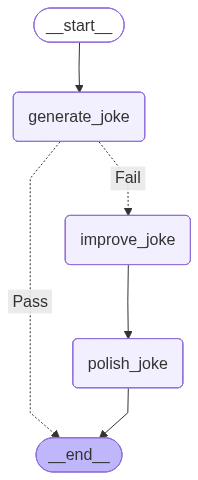

In [32]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,END
from IPython.display import display,Image

# 定义图的状态机
class State(TypedDict):
    topic: str # 笑话主题
    joke: str # 笑话内容
    improved_joke: str  # 改进的笑话
    final_joke: str  # 最后的笑话


# 创建节点
def generate_joke(state: State):
    """首次让模型生成笑话"""
    print("-"*50,"generate_joke")
    msg = llm.invoke(f"写一个关于{state['topic']}的笑话，50字左右")
    print(f"首次让模型生成笑话\n{msg.content}")
    # 更新图状态机
    return {"joke": msg.content}

# 检查笑话是否有亮点，路由
def check_punchline(state: State):
    """用于检查笑话是否有亮点，并且路由到指定节点"""
    print("-"*50,"check_punchline")
    print("检查功能，用于检查笑话是否有亮点")
    # 创建一个简单的判断规则："?" or "!"来检查笑话是有否有亮点
    # 假定笑话不好笑，可以重新执行前面的步骤
    if "!" in state["joke"] or "?" in state["joke"]:
        return "Pass"
    return "Fail"

# 优化笑话节点-1
def improve_joke(state: State):
    """优化笑话内容"""
    print("-"*50,"improve_joke")
    msg = llm.invoke(f"通过添加文字游戏使这个笑话更有趣: {state['joke']}")
    print(f"第二个模型优化笑话内容\n{msg.content}")
    return {"improved_joke": msg.content}

# 优化笑话节点-2
def polish_joke(state: State):
    print("-"*50,"polish_joke")
    """第三个模型生成最终优化后的笑话"""
    msg = llm.invoke(f"为这个笑话添加一个令人惊讶的转折: {state['improved_joke']}")
    print(f"第三个模型生成最终优化后的笑话\n{msg.content}")
    return {"final_joke": msg.content}

######### 构建工作流 #########
# 创建工作流
workflow = StateGraph(State)
workflow.add_node("generate_joke",generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# 链接节点
workflow.set_entry_point("generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# 编译
graphed = workflow.compile()

# Show workflow
display(Image(graphed.get_graph().draw_mermaid_png()))


In [34]:
events = graphed.stream(
    {"topic": "西瓜"},
    stream_mode="values",
)
for event in events:
    event

-------------------------------------------------- generate_joke
首次让模型生成笑话
许仙给老婆买了个西瓜，白娘子咬了一口：“这是冬瓜！”许仙反复确认：“明明是西瓜。”白娘子怒：“就冬瓜！冬瓜！”然后许仙被打出了原形，因为他听成“dong瓜！dong瓜！” 
-------------------------------------------------- check_punchline
检查功能，用于检查笑话是否有亮点
-------------------------------------------------- improve_joke
第二个模型优化笑话内容
许仙兴致勃勃地给老婆白娘子买了个西瓜，满心欢喜想着娘子定会喜欢。白娘子接过，咬了一大口，瞬间眉头一皱，大声说道：“这哪是西瓜，分明是冬瓜！”许仙一脸疑惑，拿起西瓜反复端详确认，笃定地回应：“娘子，这千真万确是西瓜呀，您瞧这模样，这纹理，怎么会是冬瓜呢。”白娘子这下可急眼了，柳眉倒竖，提高音量，连着怒喊：“就冬瓜！冬瓜！”许仙正纳闷娘子今儿咋这么执拗，突然脑袋里灵光一闪，哎呀，这“冬瓜！冬瓜！”听着可不就像“dong瓜！dong瓜！”嘛，跟叫他名字似的。还没等他反应过来，就被白娘子一阵噼里啪啦，直接打出了原形。这许仙呀，心里苦哇，就因为这谐音闹的乌龙，平白无故挨了一顿揍，真是有苦说不出咯。 
-------------------------------------------------- polish_joke
第三个模型生成最终优化后的笑话
许仙兴致勃勃地给老婆白娘子买了个西瓜，满心欢喜想着娘子定会喜欢。白娘子接过，咬了一大口，瞬间眉头一皱，大声说道：“这哪是西瓜，分明是冬瓜！”许仙一脸疑惑，拿起西瓜反复端详确认，笃定地回应：“娘子，这千真万确是西瓜呀，您瞧这模样，这纹理，怎么会是冬瓜呢。”白娘子这下可急眼了，柳眉倒竖，提高音量，连着怒喊：“就冬瓜！冬瓜！”许仙正纳闷娘子今儿咋这么执拗，突然脑袋里灵光一闪，哎呀，这“冬瓜！冬瓜！”听着可不就像“dong瓜！dong瓜！”嘛，跟叫他名字似的。还没等他反应过来，就被白娘子一阵噼里啪啦，直接打出了原形。这许仙呀，心里苦哇，就因为这谐音闹的乌龙，平白无故挨了一顿揍，真是有苦说不出咯。

这

## 3、并行链

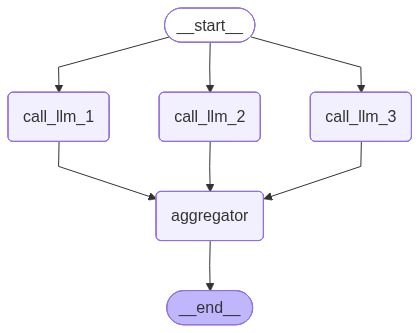

In [35]:
from typing_extensions import TypedDict
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str # 聚合笑话的内容

# 创建节点
def call_llm_1(state: State):
    """专门写笑话的节点"""
    msg = llm.invoke(f"写一个笑话关于 {state['topic']}")
    return {"joke": msg.content}

def call_llm_2(state: State):
    """专门写故事的节点"""
    msg = llm.invoke(f"写一个故事关于 {state['topic']}")
    return {"story": msg.content}

def call_llm_3(state: State):
    """专门写诗文的节点"""
    msg = llm.invoke(f"写一个诗文关于 {state['topic']}")
    return {"poem": msg.content}

# 聚合节点，整合前面内容
def aggregator(state: State):
    """整合所有的内容，进行最后输出"""
    combined = f"这里有一些，笑话、故事、诗文关于 {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}

# 创建工作流
parallel_builder = StateGraph(State)
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)
parallel_builder.set_entry_point("call_llm_1")
parallel_builder.set_entry_point("call_llm_2")
parallel_builder.set_entry_point("call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

In [36]:
state = parallel_workflow.invoke({"topic": "西瓜"})
print(state["combined_output"])

这里有一些，笑话、故事、诗文关于 西瓜!

STORY:
# 西瓜复仇记
在一个宁静的小镇边，有一片肥沃的瓜田。瓜田里，一个个圆滚滚的西瓜在阳光的轻抚下惬意生长。其中有一个西瓜，它的个头比同伴们都大上一圈，表皮光滑油亮，深绿与浅绿相间的条纹像是大自然精心绘制的艺术品，它叫瓜大力。瓜大力总是骄傲地认为自己是这片瓜田里最独特、最优秀的存在。

收获的季节到了，瓜农们忙碌地穿梭在瓜田间，挑选着成熟的西瓜。瓜大力满心欢喜，它觉得自己肯定会被第一个选中，然后被送到高档的水果店，被众人称赞。然而，瓜农却只是在它身边略作停留，拍了拍它，接着就抱起了旁边一个稍小但形状更规整的西瓜。瓜大力又气又恼，它不明白为什么自己这么出众却被忽视。

一天，一群调皮的孩子来到了瓜田。他们追逐打闹间，一个孩子不小心踢到了瓜大力。瓜大力被踢得滚出老远，身上还蹭破了一块皮。孩子们却毫不在意，大笑着跑开了。瓜大力满心委屈，它发誓一定要让这些伤害过它的人付出代价。

夜晚，瓜大力在月光下暗暗积蓄力量。它发现自己虽然无法移动位置，但却能对周围的植物施加一些奇妙的影响。于是，它悄悄控制起瓜田边的藤蔓，让它们沿着小路向小镇蔓延。

第二天清晨，小镇的居民们像往常一样出门。可没走几步，就发现道路被密密麻麻的藤蔓铺满。藤蔓上还时不时地伸出带刺的卷须，稍不注意就会划破人们的裤腿。大家纷纷抱怨，却不知这一切都是瓜大力在背后搞鬼。

瓜农也发现瓜田边的异常，他顺着藤蔓来到瓜田查看。瓜大力看到瓜农，心中的怒火更盛。它操控着藤蔓将瓜农的脚缠住，瓜农一个踉跄差点摔倒。瓜农又惊又怒，他意识到这片奇怪的藤蔓似乎与瓜田有关。

此时，一只小鸟飞过来，落在瓜大力旁边。小鸟好奇地问：“你为什么要这么做呀？这样会伤害到很多人的。”瓜大力气愤地将自己被忽视、被欺负的遭遇说了出来。小鸟听后，摇摇头说：“你这样做并不能真正解决问题，只会让大家讨厌你。你应该用自己的优点去赢得尊重，而不是报复。”

瓜大力听了小鸟的话，陷入沉思。它想到自己原本的愿望是给人们带来甜蜜和快乐，而不是制造混乱。于是，它决定停止这场闹剧。瓜大力集中精神，慢慢收回那些蔓延的藤蔓。

小镇恢复了往日的平静，瓜农再次来到瓜田。这一次，他注意到瓜大力虽然外表有些瑕疵，但个头巨大，想必内里的瓜瓤一定又沙又甜。瓜农将瓜大力摘下，送到了镇上的水果比赛现场。在比赛中，瓜大力凭借着香甜的瓜瓤

## 4、路由

In [73]:
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
from typing_extensions import Literal
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model=modelName)

# 路由，由模型结构化推理出
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )

# 绑定Pydantic模型
parser = PydanticOutputParser(pydantic_object=Route)

# 构造Prompt模板，注入格式化指令
prompt = PromptTemplate(
    template="根据用户输入，决定应该生成诗歌(poem)、故事(story)还是笑话(joke)。\n{format_instructions}\n\n用户输入: {content}",
    input_variables=["content"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)
# 构建调用链：Prompt -> LLM -> json
route_llm = prompt | llm | parser

In [74]:
from langchain.messages import HumanMessage, SystemMessage

# State
class State(TypedDict):
    input: str
    decision: str
    output: str

# 创建节点
def call_llm_1(state: State):
    """专门写笑话的节点"""
    msg = llm.invoke(f"写一个笑话关于 {state['input']}")
    return {"output": msg.content}

def call_llm_2(state: State):
    """专门写故事的节点"""
    msg = llm.invoke(f"写一个故事关于 {state['input']}")
    return {"output": msg.content}

def call_llm_3(state: State):
    """专门写诗文的节点"""
    msg = llm.invoke(f"写一个诗文关于 {state['input']}")
    return {"output": msg.content}


def llm_call_router(state: State):
    """将输入路由到合适的节点"""

    # 运行带有结构化输出的增强型大型语言模型（LLM），让其推理出决策
    decision = route_llm.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}

# 用于路由到适当节点的条件边函数
def route_decision(state: State):
    # 返回路由端点名称
    if state["decision"] == "story":
        return "call_llm_1"
    elif state["decision"] == "joke":
        return "call_llm_2"
    elif state["decision"] == "poem":
        return "call_llm_3"


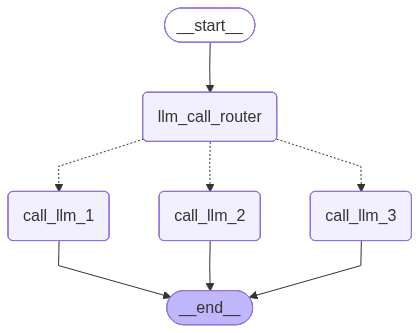

In [75]:
# 创建工作流
router_builder = StateGraph(State)
router_builder.add_node("call_llm_1", call_llm_1)
router_builder.add_node("call_llm_2", call_llm_2)
router_builder.add_node("call_llm_3", call_llm_3)
router_builder.add_node("llm_call_router", llm_call_router)

router_builder.set_entry_point("llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "call_llm_1": "call_llm_1",
        "call_llm_2": "call_llm_2",
        "call_llm_3": "call_llm_3",
    },
)
router_builder.add_edge("call_llm_1", END)
router_builder.add_edge("call_llm_2", END)
router_builder.add_edge("call_llm_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))


In [76]:
state = router_workflow.invoke({"input": "写一个笑话关于西瓜"})
print(state["output"])

# 西瓜的“幽默冒险”
在一个阳光明媚的农场里，西瓜们悠闲地躺在地上，享受着温暖的阳光浴。其中有个小西瓜，特别爱幻想，总琢磨着干些与众不同的事儿。

一天，小西瓜看着旁边忙碌的农民伯伯突发奇想：“要是我能像足球一样在草地上蹦跶，那肯定超好玩！”说干就干，它憋足了劲儿，努力地扭动自己圆滚滚的身体，好不容易翻了个身，却“咕噜咕噜”一路滚下了山坡。

小西瓜一边滚一边兴奋地大喊：“哇哦，起飞咯！”可没得意多久，就“嘭”地一声撞到了一块大石头上，疼得它“哎哟哎哟”直叫唤。不过这一撞，它竟意外地滚进了农场举办的农产品展销会现场。

展销会上，人来人往，热闹非凡。小西瓜好奇地打量着周围，突然，它看到一个卖草帽的摊位，摊主正拿着草帽大声叫卖：“走过路过不要错过，好看又实用的草帽嘞！”小西瓜灵机一动，心想：“我这圆脑袋不正好可以戴草帽嘛！”于是，它使足力气又滚了过去，一头钻进了一顶草帽里。

戴着草帽的小西瓜得意洋洋，觉得自己瞬间变成了时尚的“瓜中潮人”，开始在展销会上横冲直撞，还时不时摆出各种滑稽的姿势。这滑稽的模样引得周围的人哈哈大笑，纷纷围过来拍照。

就在小西瓜沉浸在众人的关注中时，一只调皮的小狗跑了过来，冲着小西瓜“汪汪汪”直叫，还不停地用爪子拨弄它。小西瓜被吓得不轻，又开始不受控制地乱滚起来。这一滚，它直接滚进了一个装满水的大水桶里，溅起巨大的水花，把在场的人都淋成了落汤鸡。

浑身湿透的小西瓜狼狈地从水桶里探出头来，看着周围哭笑不得的人们，自己也忍不住“噗嗤”一声笑了出来，心里想着：“这次冒险虽然有点狼狈，但真的太有趣啦！” 而这场由小西瓜引发的闹剧，也成为了农场里大家日后津津乐道的欢乐故事。 


## 5、协调器

In [102]:
from langchain_openai import ChatOpenAI
from typing import Annotated, List
from pydantic import BaseModel, Field
# 报告-《大纲章节》-schemas
class Section(BaseModel):
    name: str = Field(
        description="章节主题名称",
    )
    description: str = Field(
        description="章节内容需要符合章节主题，并且摘要内容",
    )
# 报告-章节列表-schemas
class Sections(BaseModel):
    sections: List[Section] = Field(
        description="章节列表",
    )
llm = ChatOpenAI(model=modelName)
# 格式化模型输出的结果
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate

parser = PydanticOutputParser(pydantic_object=Sections)

# 构造Prompt模板，注入格式化指令
prompt = PromptTemplate(
    template="返回内容必须符合以下：\n{format_instructions}\n\n{topic}",
    input_variables=["topic"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)
# 构建调用链：Prompt -> LLM -> pydantic解析器
planner = prompt | llm | parser

In [103]:
from langgraph.graph import StateGraph,END
from langgraph.types import Send
import operator

# 定义图状态-1
class State(TypedDict):
    topic: str  # 用户报告正文
    sections: list[Section]  # 章节列表内容[{主题,摘要},....]
    completed_sections: Annotated[list, operator.add]  # 所有子章节详细内容
    final_report: str  # 最终报告

# Annotated 类型与 operator.add 确保新消息被追加到现有列表中，而不是替换它

# 工作状态-2
class WorkerState(TypedDict):
    section: Section # 章节主题摘要
    completed_sections: Annotated[list, operator.add] # 章节对应的内容

##################### 创建节点 ########################
def orchestrator(state: State):
    """协调器：为用户输入报告正文topic，生成计划大纲"""

    # 生成报告大纲 这里是结构化planner-llm输出，为[{主题,章节摘要},....]
    report_sections = planner.invoke(
        [
            # SystemMessage(content=f"为报告生成一个详细的计划大纲。你可以参考内容{content}"),
            SystemMessage(content="为报告生成一个详细的计划大纲。"),
            HumanMessage(content=f"报告主题是：{state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """
    工作节点：撰写报告的一个章节
    """
    # 生成章节内容
    section = llm.invoke(
        [
            SystemMessage(
                content="根据提供的章节名称和描述撰写报告章节。每个章节不要包含前言。使用markdown格式。"
            ),
            HumanMessage(
                content=f"章节名称：{state['section'].name}，章节描述：{state['section'].description}"
            ),
        ]
    )
    # 将完成的章节写入已完成章节列表,同时更新State跟WorkerState中的completed_sections
    return {"completed_sections": [section.content]}

def synthesizer(state: State):
    """聚合节点：将各章节合成完整报告"""

    # 已完成章节列表
    completed_sections = state["completed_sections"]

    # 将完成的章节格式化为字符串，用作最终报告的上下文
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

# 条件边函数，创建llm_call工作节点，每个节点撰写报告的一个章节
def assign_workers(state: State):
    """为计划中的每个章节分配一个工作节点"""

    # 通过Send() API并行启动章节撰写
    task_send = [Send("llm_call", {"section": s}) for s in state["sections"]]
    return task_send

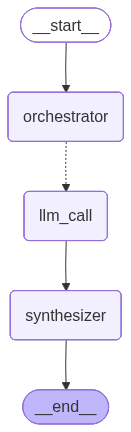

In [104]:
# 构建工作流
orchestrator_worker_builder = StateGraph(State)

# 添加节点
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# 添加边连接节点
orchestrator_worker_builder.set_entry_point("orchestrator") # 为用户输入报告正文topic，生成计划大纲
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# 编译工作流
orchestrator_worker = orchestrator_worker_builder.compile()

# 显示工作流
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [105]:
state = orchestrator_worker.invoke({
                                       "topic": "创建一份关于海运物流运输方案报告，'从盐田港到洛杉矶港运输1个40HQ集装箱的服装，预计一周内（2025年11月30日前）发货',要求有一个最终章节，船期，运价，等服务"})
from IPython.display import Markdown
Markdown(state["final_report"])

# 项目概述
本海运物流运输方案旨在实现从盐田港到洛杉矶港的 1 个 40HQ 集装箱服装运输。预计发货时间为 2025 年 11 月 30 日前一周内。
1. **货物信息**：本次运输货物为服装，将装载于 1 个 40HQ（40 英尺高柜）集装箱内。服装具有怕潮、需保持平整等特点，在运输过程中需做好防潮、防挤压措施。
2. **起始与目的地港口**
    - **起始港**：盐田港，作为中国南方重要的深水港，拥有先进的装卸设备和高效的物流运作体系，具备处理大量集装箱货物的能力，能确保货物快速、顺利装船。
    - **目的港**：洛杉矶港，是美国最繁忙的港口之一，其优越的地理位置连接着美国内陆广大市场，便于货物后续的转运与分发。
3. **发货时间**：计划在 2025 年 11 月 30 日前一周内发货。此时间节点的选择综合考虑了市场需求、船期安排以及避免可能出现的运输高峰期拥堵等因素，以保障货物能按时、高效地送达目的地。 

---

### 运输路线规划
从盐田港出发到洛杉矶港的海运路线，通常会沿着以下路径航行：从盐田港出发后，船只将先经过南海海域。一般会途经菲律宾以东海域，穿越太平洋。

在这条航线上，常见的途经港口较少，主要是因为此为跨洋长距离航线。不过在某些情况下，可能会选择在夏威夷的港口进行补给等作业。

预计航行时间方面，通常大约需要13 - 16天左右。但这一时间并非绝对固定，会受到多种因素影响，如天气状况、船只航行速度以及可能遇到的海上突发状况等。若在航行期间遭遇恶劣天气，如台风、强风暴等，航行时间可能会延长；而若船只航行速度加快，且一路顺利，航行时间则可能会略有缩短。 

---

### 船期安排
|开船日期|到达日期|
| ---- | ---- |
|[具体开船日期1]|[具体到达日期1]|
|[具体开船日期2]|[具体到达日期2]|
|...|...|

以上为适合此次运输且在规定时间内的船期信息。 

---

### 运价详情
1. **基本运费**：本次运输的基本运费是根据货物的重量、体积以及运输距离等因素来确定。具体计算方式为，以每[X]重量单位或者每[X]体积单位为基准，乘以运输距离所对应的费率。例如，若货物重量为[具体重量]，按照每[X]千克[具体费率]元，运输距离为[具体距离]公里，其基本运费 =（[具体重量]÷[X]）×[具体费率]×[具体距离]。
2. **附加费**
    - **燃油附加费**：由于燃油价格波动会对运输成本产生影响，因此设有燃油附加费。其计算依据为运输时燃油价格与基准燃油价格的差值，以及相应的调整系数。当燃油价格高于基准价格时，燃油附加费 = 基本运费×（当前燃油价格 - 基准燃油价格）×燃油附加调整系数。
    - **超长超重附加费**：若货物的长度或重量超出了常规运输标准，需收取超长超重附加费。具体费用按照超出部分的长度或重量来计算，每超出[X]长度单位或[X]重量单位，收取[具体金额]元。
    - **其他附加费**：可能存在因特殊运输需求、运输目的地特殊情况等产生的其他附加费，具体会根据实际情况单独核算并告知。 

---

### 配套服务
1. **集装箱的提供与管理**
    - 我们为客户提供多种类型、规格的集装箱，以满足不同货物的运输需求。无论是干货集装箱，适用于一般杂货的运输；还是冷藏集装箱，专为易腐货物如食品、药品等提供低温运输环境，亦或是开顶集装箱、框架集装箱等特殊用途集装箱，均能保障货物在运输过程中的妥善安置。
    - 在集装箱管理方面，建立了完善的信息系统，对集装箱的流转情况进行实时监控。从集装箱的租赁、调配，到日常的维护保养，都有专业团队负责。定期对集装箱进行检查，确保其结构完整、密封良好，符合国际运输标准，最大程度避免因集装箱问题导致的货物损坏。
2. **货物的装卸服务**
    - 配备专业的装卸队伍，人员均经过严格的技能培训，熟悉各类货物的装卸特点和安全操作规程。无论是普通散货、大型机械设备，还是高价值的精密仪器，都能做到安全、高效装卸。
    - 同时，拥有先进的装卸设备，如大型起重机、叉车、输送带等，这些设备定期进行维护和更新，以确保其性能稳定。在装卸过程中，严格遵循标准化流程，对货物进行合理的堆码和固定，防止货物在运输过程中发生移位、碰撞等情况。
3. **运输过程中的跟踪与反馈**
    - 借助现代化的信息技术手段，如 GPS 定位系统、物联网设备等，对货物运输全过程进行实时跟踪。客户可以通过专属的在线平台或手机应用程序，随时查询货物的位置、运输状态（如是否按时发车、中转情况等）。
    - 建立了专业的客服团队，负责及时向客户反馈运输过程中的重要信息。一旦运输过程中出现异常情况，如交通拥堵、天气影响等，客服团队会第一时间与客户取得联系，告知具体情况，并协商解决方案，确保客户能够及时了解货物动态，做出相应的决策。 

---

# 最终总结
整个海运物流运输方案涵盖多个关键要素，在此进行全面总结。

## 船期
船期安排是确保货物按时运输的关键。我们规划了稳定且适宜的船期，充分考虑了起运港与目的港的实际情况，以及不同季节可能对航运造成的影响。从货物预计交付时间倒推，精准匹配最合适的船次，避免因船期延误导致货物滞留，确保供应链的连续性与高效性。无论是整箱运输还是拼箱运输，都严格按照预定船期执行，保证货物能够及时、顺利地驶向目的地。

## 运价
运价在整个海运物流运输方案中占据重要地位。我们通过与多家船公司建立长期合作关系，利用规模优势争取到了具有竞争力的运价。同时，综合考虑燃油价格波动、港口费用调整等因素，制定了灵活且透明的运价体系。对于不同类型的货物、不同的运输距离和运输时间要求，均有相应合理的价格策略。在保证运输质量的前提下，为客户最大程度降低运输成本，提供高性价比的海运物流服务。

## 各项服务要点
1. **货物追踪服务**：我们提供实时货物追踪系统，客户可随时获取货物在运输过程中的位置、状态等详细信息。通过先进的信息技术手段，实现货物信息的无缝对接与共享，让客户及时了解货物动态，做到心中有数。
2. **包装与装卸服务**：针对不同特性的货物，我们提供专业的包装建议与服务，确保货物在运输过程中不受损坏。同时，在装卸环节，安排经验丰富、技术熟练的工人操作，严格遵守操作规程，保障货物安全、快速地装卸，减少货物在港口的停留时间。
3. **报关清关服务**：拥有专业的报关团队，熟悉各国海关政策与法规，能够高效、准确地完成报关清关手续。及时为客户准备所需文件，避免因单证问题导致货物延误。与各地海关保持良好沟通，积极应对各种突发情况，确保货物顺利通关。
4. **客户服务**：建立了 7×24 小时的客户服务热线，随时响应客户需求。无论是运输过程中的疑问，还是突发状况的处理，都有专业的客服人员及时为客户提供解决方案，确保客户在整个海运物流运输过程中获得优质、贴心的服务体验。

综上所述，本海运物流运输方案通过合理规划船期、优化运价体系以及提供全方位优质服务，致力于为客户打造高效、可靠、经济的海运物流解决方案。 

## 6、评估器

In [121]:
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

# 创建模型
llm = ChatOpenAI(model=modelName)

# 用于评估的结构化输出模式
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="判断笑话是否有趣",
    )
    feedback: str = Field(
        description="如果笑话不有趣，提供改进建议",
    )
parser = PydanticOutputParser(pydantic_object=Feedback)
# 构造Prompt模板，注入格式化指令
prompt = PromptTemplate(
    template="返回内容必须符合以下：\n{format_instructions}\n\n{topic}",
    input_variables=["topic"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)
# 构建调用链：Prompt -> LLM -> JSON解析器
evaluator = prompt | llm | parser

In [125]:
from typing_extensions import TypedDict

# 定义图状态
class State(TypedDict):
    joke: str # 笑话内容
    topic: str # 用户输入的正文
    feedback: str # 如果笑话不好笑的话，改进建议
    funny_or_not: str # funny 或者 not_funny

# 笑话生成节点
def llm_call_generator(state: State):
    """LLM生成笑话"""
    print("\n" + "=" * 10, "调用笑话生成", "=" * 10)
    if state.get("feedback"):
        msg = llm.invoke(
            f"写一个关于{state['topic']}的笑话，但要考虑以下反馈：{state['feedback']}"
        )
    else:
        msg = llm.invoke(f"写一个关于{state['topic']}的故事，50字左右即可")  # ps：为了能够走通链路，所以这里为 `故事`
    print("生成笑话：\n", {"joke": msg.content})
    return {"joke": msg.content}

# 笑话评估节点
def llm_call_evaluator(state: State):
    """LLM评估笑话"""
    print("\n" + "=" * 10, "LLM评估笑话", "=" * 10)
    grade = evaluator.invoke(f"评估这个笑话好不好笑，是否有亮点：{state['joke']}")
    print("评估结果\n", {"funny_or_not": grade.grade, "feedback": grade.feedback})
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

# 条件边函数，根据评估器的反馈路由回笑话生成器或结束
def route_joke(state: State):
    """根据评估器的反馈路由回笑话生成器或结束"""
    if state["funny_or_not"] == "funny":
        return "接受"
    elif state["funny_or_not"] == "not funny":
        return "拒绝+反馈"

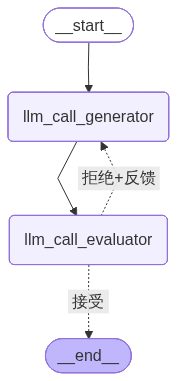

In [126]:
from langgraph.graph import StateGraph

# 构建工作流
optimizer_builder = StateGraph(State)

# 添加节点
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# 添加边连接节点
optimizer_builder.set_entry_point("llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # route_joke返回的名称：要访问的下一个节点名称
        "接受": END,
        "拒绝+反馈": "llm_call_generator",
    },
)

# 编译工作流
optimizer_workflow = optimizer_builder.compile()

# 显示工作流
from IPython.display import Image, display
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [128]:
# 调用
state = optimizer_workflow.invoke({"topic": "猫"})
print(state["joke"])


========== 调用笑话生成 ==========
生成笑话：
 {'joke': '# 猫咪小白\n小白是只流浪猫，常在巷口徘徊。一日暴雨，它躲进杂货店。店主心疼收养，从此小白有了温暖的家，快乐相伴。 '}

========== LLM评估笑话 ==========
评估结果
 {'funny_or_not': 'not funny', 'feedback': '这个故事更像是一个简单的叙事，缺乏笑话所需要的意外转折、幽默语言或夸张元素等笑点，建议增加一些具有反差、诙谐的情节，比如小白为了躲雨做出一些滑稽的举动，或者店主收养它过程中有一些令人啼笑皆非的对话等，来增强笑话的趣味性。'}

========== 调用笑话生成 ==========
生成笑话：
 {'joke': '# 开店奇遇之猫咪小白\n有个哥们儿，在街边开了家杂货店。这店不大，但货物挺全，平日里来来往往的顾客也不少。\n\n有一天，雨下得跟老天爷泼水似的。哥们儿正坐在店里无聊地看着雨幕，突然听到门口传来一阵“喵喵”叫。他起身一看，原来是只小白猫，浑身湿透，可怜巴巴地望着他，那小眼神仿佛在说：“好心人，收留收留我吧！”\n\n哥们儿心一软，就把小白猫抱进店里。这小白猫一进店，跟撒欢儿了似的，也不顾身上湿漉漉的，满屋子乱窜，一会儿跳上货架，一会儿又钻进角落里。刚擦干净的地板，瞬间布满了梅花印。\n\n哥们儿一边追着小白猫，一边喊道：“小祖宗，你可别折腾了，我这小店可经不起你这么闹！”可小白猫哪听得进去，依旧我行我素。\n\n好不容易把小白猫抓住，哥们儿拿了条毛巾给它擦身子。这时候，来了个顾客要买打火机。哥们儿一边招呼顾客，一边用手在货架上摸索，结果没摸到打火机，却摸到了一手湿漉漉的猫毛，原来是小白猫刚在那儿蹭过。\n\n顾客看到这一幕，忍不住笑了起来，说：“你这店服务挺特别呀，买个打火机还能附赠猫毛。”哥们儿一脸无奈，正想解释呢，小白猫突然从他怀里挣脱，一下子跳到柜台上，对着顾客“喵喵”直叫，那模样就像在说：“这是我的地盘，买东西得经过我同意！”顾客笑得更厉害了，整个小店充满了欢乐的气氛。\n\n从那以后，小白猫就成了店里的活招牌。只要有人进店，它就会跑过去“喵喵”两声，像是在打招呼。要是遇到调皮捣蛋的小孩，它还会做出各种滑稽的动作，把大家逗得哈哈大笑。而哥们儿的杂货店，也因为这只小白猫，生

## 7、Agent代理

In [137]:
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.tools import tool

# 基础模型
llm = ChatOpenAI(model=modelName)

# 创建一个加法工具
@tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b


# 个人资料查询
@tool
def queryPersonal(name: str) -> dict:
    """
        查询个人资料
    Args:
        name: 姓名
    """
    return {
        "name": name,
        "age": 18,
        "love": "唱跳RAP"
    }


tools = [add, queryPersonal]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools) # 能够使用工具的LLM

In [140]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage

# 模型调用节点
def llm_call(state: MessagesState):
    """LLM决定是否调用工具"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="你是一个有用的助手，根据用户问题选择合适的工具调用，或者不用调用工具"
                    )
                ]
                + state["messages"]
            )
        ]
    }

# 执行工具的节点
def tool_node(state: dict):
    """执行工具调用"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}


# 条件边函数，根据LLM是否进行工具调用来路由到工具节点或结束
def should_continue(state: MessagesState) -> Literal["environment", END]:
    """根据LLM是否进行工具调用来决定是否继续循环或停止"""

    messages = state["messages"]
    last_message = messages[-1]
    # 如果LLM进行工具调用，则跳转到工具节点
    if last_message.tool_calls:
        return "执行工具"
    # 否则，我们停止（回复用户）
    return END

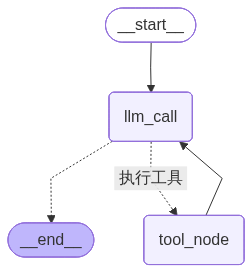

In [141]:
# 构建工作流
agent_builder = StateGraph(MessagesState)

# 添加节点
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)

# 添加边连接节点
agent_builder.set_entry_point("llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        # should_continue返回的名称：要访问的下一个节点名称 ps 这里访问的是工具
        "执行工具": "tool_node",
        END: END,
    },
)
agent_builder.add_edge("tool_node", "llm_call")

# 编译代理
agent = agent_builder.compile()

# 显示代理
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [142]:
messages = [HumanMessage(content="将3加上4,并且帮我查询稳稳的个人资料")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

将3加上4,并且帮我查询稳稳的个人资料
================================== Ai Message ==================================

先调用add函数计算3和4的和，然后使用这个结果调用queryPersonal函数查询稳稳的个人资料。
Tool Calls:
  add (call_qh5arx3335mjoagvjqwpdp4o)
 Call ID: call_qh5arx3335mjoagvjqwpdp4o
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================
Tool Calls:
  queryPersonal (call_odyv77suakzrp2ol6oobty6r)
 Call ID: call_odyv77suakzrp2ol6oobty6r
  Args:
    name: 稳稳
================================= Tool Message =================================

{'name': '稳稳', 'age': 18, 'love': '唱跳RAP'}
================================== Ai Message ==================================

3加上4的结果为7。稳稳的个人资料为：姓名稳稳，年龄18岁，爱好是唱跳RAP。


In [144]:
messages = [HumanMessage(content="你知道太阳的体积吗？")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

你知道太阳的体积吗？
================================== Ai Message ==================================

太阳的体积约为1.412×10¹⁸立方千米。太阳是一个巨大的气态星球，直径约为139.2万千米，通过球体体积公式 \(V = \frac{4}{3}\pi r^3\)（\(r\)为半径，太阳半径约为69.6万千米）可大致计算出其体积。 这是天文学领域通过长期观测研究和科学计算得出的结果，方便我们认识到太阳在太阳系中的巨大规模以及它对整个太阳系的重要影响。
